<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/Semana8Dia3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIA 3: AUDITORIA AVANÇADA - SUPRESSÃO DE NÃO MÁXIMOS (NMS)
-> IA processou a imagem e gerou 4 tensores sobrepostos...
-> O algoritmo NMS apagou as redundâncias. Restaram: 1 caixa(s) final(is).


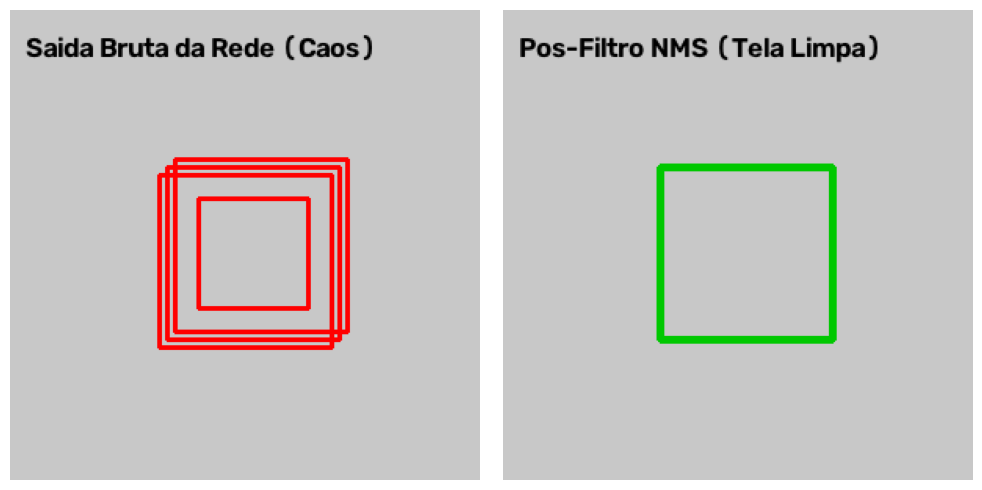

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("="*80)
print("DIA 3: AUDITORIA AVANÇADA - SUPRESSÃO DE NÃO MÁXIMOS (NMS)")
print("="*80)

def calcular_iou_array(caixa_rainha, lista_caixas):
    """Calcula o IoU de forma vetorizada usando NumPy (Alta Performance)"""
    xA = np.maximum(caixa_rainha[0], lista_caixas[:, 0])
    yA = np.maximum(caixa_rainha[1], lista_caixas[:, 1])
    xB = np.minimum(caixa_rainha[2], lista_caixas[:, 2])
    yB = np.minimum(caixa_rainha[3], lista_caixas[:, 3])

    intersecao = np.maximum(0, xB - xA) * np.maximum(0, yB - yA)
    area_rainha = (caixa_rainha[2] - caixa_rainha[0]) * (caixa_rainha[3] - caixa_rainha[1])
    area_caixas = (lista_caixas[:, 2] - lista_caixas[:, 0]) * (lista_caixas[:, 3] - lista_caixas[:, 1])

    uniao = area_rainha + area_caixas - intersecao
    return intersecao / (uniao + 1e-6)

def non_maximum_suppression(caixas, confiancas, limite_iou=0.5):
    """Filtra as caixas sobrepostas mantendo apenas as predições de maior confiança."""
    if len(caixas) == 0: return []

    caixas = np.array(caixas)
    confiancas = np.array(confiancas)
    caixas_salvas = []

    # Ordena os índices das confiancas da menor para a maior
    indices_ordenados = np.argsort(confiancas)

    while len(indices_ordenados) > 0:
        # Pega a caixa com a MAIOR confiança (o último elemento do array ordenado)
        idx_maior = indices_ordenados[-1]
        caixa_rainha = caixas[idx_maior]
        caixas_salvas.append(caixa_rainha.tolist()) # Salva a rainha

        # Se só tinha ela, acaba o loop
        if len(indices_ordenados) == 1: break

        # Pega todas as outras caixas que sobraram
        indices_restantes = indices_ordenados[:-1]
        caixas_restantes = caixas[indices_restantes]

        # Calcula o grau de sobreposição (IoU) delas em relação à caixa rainha
        ious = calcular_iou_array(caixa_rainha, caixas_restantes)

        # Filtro: Mantém vivos apenas os índices das caixas que NÃO estão muito sobrepostas (IoU baixo)
        # Se o IoU for alto, significa que é o mesmo objeto, então apagamos!
        indices_ordenados = indices_restantes[ious < limite_iou]

    return caixas_salvas

# ==============================================================================
# SIMULAÇÃO VISUAL DO FILTRO NMS
# ==============================================================================
# Simulamos a IA enxergando 1 capacete, mas gerando 4 caixas inseguras sobrepostas
caixas_inseguras = [
    [100, 100, 210, 210], # Caixa A (Confiança: 98%) -> A Rainha
    [105, 95, 215, 205],  # Caixa B (Confiança: 85%) -> Escorregou pra cima
    [95, 105, 205, 215],  # Caixa C (Confiança: 70%) -> Escorregou pra baixo
    [120, 120, 190, 190]  # Caixa D (Confiança: 40%) -> Caixa espremida dentro
]
confiancas_brutas = [0.98, 0.85, 0.70, 0.40]

print("-> IA processou a imagem e gerou 4 tensores sobrepostos...")
caixas_filtradas = non_maximum_suppression(caixas_inseguras, confiancas_brutas, limite_iou=0.4)
print(f"-> O algoritmo NMS apagou as redundâncias. Restaram: {len(caixas_filtradas)} caixa(s) final(is).")

# Desenhando para a turma ver a limpeza
tela_bruta = np.ones((300, 300, 3), dtype=np.uint8) * 200
tela_limpa = tela_bruta.copy()

# Desenhando o caos antes do NMS
for cx in caixas_inseguras:
    cv2.rectangle(tela_bruta, (cx[0], cx[1]), (cx[2], cx[3]), (0, 0, 255), 2)
cv2.putText(tela_bruta, "Saida Bruta da Rede (Caos)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

# Desenhando o resultado após NMS
for cx in caixas_filtradas:
    cv2.rectangle(tela_limpa, (cx[0], cx[1]), (cx[2], cx[3]), (0, 200, 0), 4)
cv2.putText(tela_limpa, "Pos-Filtro NMS (Tela Limpa)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(tela_bruta, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tela_limpa, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()